In [135]:
import pandas as pd
import json
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pytz
import requests
import psycopg2

In [136]:
def read_db_credentials(path="data/config.txt"):
    creds = {}
    with open(path, "r") as f:
        for line in f:
            key, value = line.strip().split("=")
            creds[key] = value
    return creds

def connect_to_db(creds):
    return psycopg2.connect(
        host=creds["host"],
        port=creds["port"],
        dbname=creds["database"],
        user=creds["user"],
        password=creds["password"]
    )


In [137]:
cutoff =  pd.Timestamp.now().normalize()   - pd.Timedelta(days=365)
cutoff = pytz.timezone("Europe/Berlin").localize(cutoff)
with open("export.json", "r") as f:
        health_data = json.load(f)
        
health_records = health_data["HealthData"]["Record"]

with open("strava_export_combined.json") as f:
    strava_data = json.load(f)


In [138]:
all_types = set(
    entry.get("@type")
    for entry in health_records
    if isinstance(entry, dict) and "@type" in entry
)
print(all_types)


{'HKQuantityTypeIdentifierWalkingDoubleSupportPercentage', 'HKQuantityTypeIdentifierWalkingAsymmetryPercentage', 'HKDataTypeSleepDurationGoal', 'HKQuantityTypeIdentifierAppleWalkingSteadiness', 'HKCategoryTypeIdentifierSleepAnalysis', 'HKCategoryTypeIdentifierHeadphoneAudioExposureEvent', 'HKQuantityTypeIdentifierDietaryWater', 'HKQuantityTypeIdentifierHeadphoneAudioExposure', 'HKQuantityTypeIdentifierWalkingStepLength', 'HKQuantityTypeIdentifierBodyMass', 'HKQuantityTypeIdentifierDietaryEnergyConsumed', 'HKQuantityTypeIdentifierActiveEnergyBurned', 'HKQuantityTypeIdentifierFlightsClimbed', 'HKQuantityTypeIdentifierWalkingSpeed', 'HKQuantityTypeIdentifierBasalEnergyBurned', 'HKQuantityTypeIdentifierHeight', 'HKQuantityTypeIdentifierDistanceWalkingRunning', 'HKQuantityTypeIdentifierStepCount'}


In [139]:
# Top-Level Keys anzeigen
data = strava_data
import json

def print_json_structure(data, indent=0):
    spacer = "  " * indent
    if isinstance(data, dict):
        for key, value in data.items():
            print(f"{spacer}\"{key}\": ", end="")
            if isinstance(value, (dict, list)):
                print()
                print_json_structure(value, indent + 1)
            else:
                print(type(value).__name__)
    elif isinstance(data, list):
        print(f"{spacer}[")
        if data:
            print_json_structure(data[0], indent + 1)
        else:
            print(f"{'  ' * (indent + 1)}<empty>")
        print(f"{spacer}]")
    else:
        print(f"{spacer}{type(data).__name__}")

# JSON-Datei laden

# Struktur ausgeben
print_json_structure(data)


"flags": 
  [
    <empty>
  ]
"media": 
  [
    <empty>
  ]
"contacts": 
  [
    <empty>
  ]
"segments": 
  [
    <empty>
  ]
"privacy_zones": 
  [
    <empty>
  ]
"local_legend_segments": 
  [
    <empty>
  ]
"applications": 
  [
    <empty>
  ]
"orders": 
  [
    <empty>
  ]
"social_settings": 
  [
    "Automatisches Teilen auf Facebook ist aktiviert": str
    "Beliebte Garmin-Segmente aktiviert": str
    "Standard-Highlight-Bild für Aktivitäten": str
    "Hauptclub-ID-Nummer": float
    "Kontakte synchronisieren aktiviert": str
    "Keine Mitteilungen über meine Aktivitäten an meine Abonnenten senden": str
  ]
"bikes": 
  [
    <empty>
  ]
"starred_segments": 
  [
    <empty>
  ]
"posts": 
  [
    <empty>
  ]
"global_challenges": 
  [
    <empty>
  ]
"shoes": 
  [
    <empty>
  ]
"components": 
  [
    <empty>
  ]
"connected_apps": 
  [
    "Anwendungsname aktiviert": str
  ]
"general_preferences": 
  [
    "Geburtsdatum": str
    "Gewicht": str
    "Funktionale Schwellenleistung": 

In [140]:
sleep_records = [
    entry for entry in health_records
    if isinstance(entry, dict) and entry.get("@type") == "HKCategoryTypeIdentifierSleepAnalysis"
]

df_sleep = pd.DataFrame([{
    "start": pd.to_datetime(entry["@startDate"]),
    "end": pd.to_datetime(entry["@endDate"]),
    "value": entry["@value"] # Schlafphase
} for entry in sleep_records])

df_sleep = df_sleep[df_sleep["start"] >= cutoff]

#print(df_sleep)
df_sleep["duration_hr"] = (df_sleep["end"] - df_sleep["start"]).dt.total_seconds() / 3600
df_sleep["date"] = df_sleep["start"].dt.date
sleep_per_night = df_sleep.groupby("date")["duration_hr"].sum().reset_index()
awakenings_per_night = df_sleep.groupby("date").size().reset_index(name="phases")
sleep_summary = pd.merge(sleep_per_night, awakenings_per_night, on="date")
sleep_summary.columns = ["date", "total_sleep_hr", "sleep_phases"]

print(sleep_summary)


           date  total_sleep_hr  sleep_phases
0    2024-06-21        7.436667             8
1    2024-06-22        9.272222             6
2    2024-06-23        9.818611            18
3    2024-06-24        7.158056             3
4    2024-06-25        7.418889            11
..          ...             ...           ...
149  2024-11-19        6.670556            15
150  2024-11-20        6.940278             4
151  2024-11-21        6.445833            10
152  2024-11-22        6.913611            10
153  2024-11-23        8.185278            19

[154 rows x 3 columns]


In [141]:
step_records = [
    entry for entry in health_records
    if isinstance(entry, dict) and entry.get("@type") == "HKQuantityTypeIdentifierStepCount"
]

df_steps= pd.DataFrame([{
    "startDate": pd.to_datetime(entry["@startDate"]),
    "endDate": pd.to_datetime(entry["@endDate"]),
    "value": entry["@value"] # Schlafphase
} for entry in step_records])

df_steps = df_steps[df_steps["startDate"] >= cutoff]

In [142]:

daily_steps  = df_steps    # Optional: Umwandlung in passende Datentypen
daily_steps["startDate"] = pd.to_datetime(daily_steps ["startDate"])
daily_steps["endDate"] = pd.to_datetime(daily_steps ["endDate"])
daily_steps["value"] = pd.to_numeric(daily_steps ["value"])
 


daily_steps = daily_steps.groupby("startDate")["value"].sum().reset_index()

# Optional: Spalte umbenennen für Lesbarkeit
daily_steps.columns = ["date", "total_steps"]

print(daily_steps.head())
# Neuberechnung der Dauer in Minuten und Schritttempo


                       date  total_steps
0 2024-06-21 01:40:15+02:00           25
1 2024-06-21 07:49:54+02:00           26
2 2024-06-21 08:00:48+02:00           40
3 2024-06-21 08:10:51+02:00          509
4 2024-06-21 08:20:51+02:00          503


In [143]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daypart_order = ["Night", "Early Morning", "Morning", "Noon", "Afternoon", "Evening"]

df_dtactivity =df_steps 

df_dtactivity["startDate"] = pd.to_datetime(df_dtactivity["startDate"])

# 1. Wochentag extrahieren (z. B. "Montag")
df_dtactivity["weekday"] = df_dtactivity["startDate"].dt.day_name(locale="en_GB")  # für deutschsprachige Ausgabe

# 2. Tageszeit-Kategorie erstellen
def get_day_part(hour):
    if 0 <= hour < 4:
        return "Night"
    elif 6 <= hour < 8:
        return "Early Morning"
    elif 8 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 16:
        return  "Noon"
    elif 16 <= hour < 20:
        return "Afternoon"
    else:
        return "Evening"

df_dtactivity["day_part"] = df_dtactivity["startDate"].dt.hour.apply(get_day_part)

# 3. Gruppieren nach Wochentag & Tageszeit, dann durchschnittliche Schritte berechnen

df_dtactivity["date"] = df_dtactivity["startDate"].dt.date
df_dtactivity = df_dtactivity.groupby(["date","weekday", "day_part"])["value"].sum().reset_index()
print(df_dtactivity)
df_dtactivity = df_dtactivity.groupby(["weekday", "day_part"])["value"].mean().reset_index()

# 4. Umbenennen
df_dtactivity.columns = ["weekday", "day_part", "steps"]

# Optional: Wochentag sortieren (Montag zuerst)

df_dtactivity["weekday"] = pd.Categorical(df_dtactivity["weekday"], categories=weekday_order, ordered=True)
df_dtactivity["day_part"] = pd.Categorical(df_dtactivity["day_part"], categories=daypart_order, ordered=True)

# Sortieren
df_dtactivity = df_dtactivity.sort_values(["weekday", "day_part"]).reset_index(drop=True)
# Ergebnis anzeigen
display(df_dtactivity)


            date   weekday       day_part  value
0     2024-06-21    Friday      Afternoon   6855
1     2024-06-21    Friday  Early Morning     26
2     2024-06-21    Friday        Evening   5565
3     2024-06-21    Friday        Morning   2805
4     2024-06-21    Friday          Night     25
...          ...       ...            ...    ...
1761  2025-06-20    Friday        Morning   6504
1762  2025-06-20    Friday           Noon     76
1763  2025-06-21  Saturday        Morning   2305
1764  2025-06-21  Saturday          Night   2190
1765  2025-06-21  Saturday           Noon    182

[1766 rows x 4 columns]


,weekday,day_part,steps
0,Monday,Night,315.516129
1,Monday,Early Morning,424.181818
2,Monday,Morning,1138.714286
3,Monday,Noon,1617.769231
4,Monday,Afternoon,2868.423077
5,Monday,Evening,2484.730769
6,Tuesday,Night,951.428571
7,Tuesday,Early Morning,1455.368421
8,Tuesday,Morning,1290.153846
9,Tuesday,Noon,1695.764706


['Night\n(0–4)', 'Early Morning\n(4–8)', 'Morning\n(8–12)', 'Noon\n(12–16)', 'Afternoon\n(16–20)', 'Evening\n(20–24)']
Categories (6, object): ['Night\n(0–4)' < 'Early Morning\n(4–8)' < 'Morning\n(8–12)' < 'Noon\n(12–16)' < 'Afternoon\n(16–20)' < 'Evening\n(20–24)']


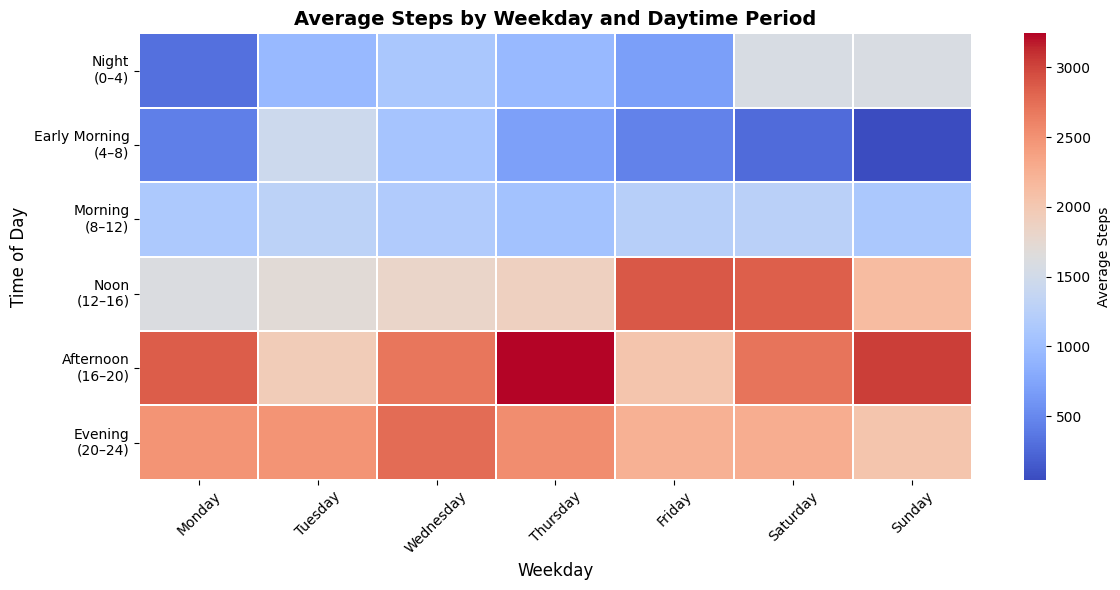

In [144]:



# Neue englische + zeitspezifische Labels
daypart_labels = {
    "Night": "Night\n(0–4)",
    "Early Morning": "Early Morning\n(4–8)",
    "Morning": "Morning\n(8–12)",
    "Noon": "Noon\n(12–16)",
    "Afternoon": "Afternoon\n(16–20)",
    "Evening": "Evening\n(20–24)"
}

# Wenn nötig, erst umbenennen
df_dtactivity["day_part"] = df_dtactivity["day_part"].cat.rename_categories(daypart_labels)


# Kategorische Sortierung (für Ordnung in Achsen)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daypart_order = list(daypart_labels.values())

df_dtactivity["weekday"] = pd.Categorical(df_dtactivity["weekday"], categories=weekday_order, ordered=True)
df_dtactivity["day_part"] = pd.Categorical(df_dtactivity["day_part"], categories=daypart_order, ordered=True)
print(df_dtactivity["day_part"].unique())

# Heatmap-Daten vorbereiten
heatmap_data = df_dtactivity.pivot(index="day_part", columns="weekday", values="steps")

# Heatmap zeichnen
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    annot=False,
    cbar_kws={'label': 'Average Steps'},
    linewidths=0.3,
    linecolor='white'
)
plt.title("Average Steps by Weekday and Daytime Period", fontsize=14, weight='bold')
plt.xlabel("Weekday", fontsize=12)
plt.ylabel("Time of Day", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



In [145]:

df_walks = df_steps
df_walks = df_walks.sort_values("startDate").reset_index(drop=True)

clusters = []
current_cluster = [df_walks.iloc[0]]

for i in range(1, len(df_walks)):
    previous = current_cluster[-1]
    current = df_walks.iloc[i]
    
    time_gap = (current["startDate"] - previous["endDate"])
    
    if time_gap <= timedelta(minutes=5):
        current_cluster.append(current)
    else:
        clusters.append(current_cluster)
        current_cluster = [current]

# letzte Gruppe nicht vergessen
clusters.append(current_cluster)

# Aggregation
aggregated = []

for group in clusters:
    group_df = pd.DataFrame(group)
    start = group_df["startDate"].min()
    end = group_df["endDate"].max()
    total_steps = group_df["value"].sum()
    duration_min = (end - start).total_seconds() / 60
    km = total_steps * 0.762 / 1000
    speed_kmh = km / (duration_min / 60) if duration_min > 0 else 0

    aggregated.append({
        "start": start,
        "end": end,
        "steps": total_steps,
        "duration_min": duration_min,
        "estimated_km": km,
        "estimated_speed_kmh": speed_kmh
    })

# In DataFrame umwandeln
df_agg = pd.DataFrame(aggregated)

# Spaziergänge filtern: Dauer 20–90 Min, Geschwindigkeit 2–5 km/h
df_agg["vermutlich_spaziergang"] = df_agg["duration_min"].between(20, 120) & df_agg["estimated_speed_kmh"].between(2,7.5 )& (df_agg["estimated_km"] > 3)

# Ausgabe
df_walks = df_agg[df_agg["vermutlich_spaziergang"]].copy()

# Neue Spalten anlegen und umbenennen
df_walks["activity"] = "Walk"
df_walks["timestamp"] = df_walks["start"]
df_walks["duration"] = df_walks["duration_min"]
df_walks["distance"] = df_walks["estimated_km"]
df_walks["type"] = "Wellness"

# Nur relevante Spalten
df_walks= df_walks[["activity", "timestamp", "duration", "distance", "type"]]

# Optional: auf sinnvolle Nachkommastellen runden
df_walks["duration"] = df_walks["duration"].round(2)
df_walks["distance"] = df_walks["distance"].round(3)
print(df_walks)
print(len(df_walks))


     activity                 timestamp  duration  distance      type
178      Walk 2024-06-28 22:53:05+02:00     71.82     3.984  Wellness
179      Walk 2024-06-29 00:21:44+02:00     54.70     3.350  Wellness
212      Walk 2024-06-30 14:17:05+02:00     58.35     4.721  Wellness
310      Walk 2024-07-04 18:43:12+02:00     62.72     3.018  Wellness
758      Walk 2024-07-26 19:54:40+02:00     67.47     3.941  Wellness
...       ...                       ...       ...       ...       ...
7357     Walk 2025-06-09 19:48:34+02:00     64.42     6.292  Wellness
7420     Walk 2025-06-12 16:51:58+02:00    110.68    10.339  Wellness
7488     Walk 2025-06-15 20:34:52+02:00    107.87    10.578  Wellness
7517     Walk 2025-06-17 07:46:27+02:00     66.77     5.897  Wellness
7576     Walk 2025-06-20 07:38:30+02:00    111.17     6.089  Wellness

[105 rows x 5 columns]
105


In [146]:
activities = strava_data.get("activities", [])

strava_activity_types = [
    "Lauf", "Traillauf", "Spaziergang", "Wandern", "Virtueller Lauf",
    "Radfahrt", "Mountainbike-Fahrt", "Gravel-Fahrt", "E-Bike-Radfahrt", "E-Mountainbike-Fahrt",
    "Velomobil", "Virtuelle Radfahrt", "Kanu", "Kajakfahrt", "Kitesurfen", "Rudern",
    "Stand-up-Paddling", "Surfen", "Schwimmen", "Windsurfen", "Eislaufen", "Ski Alpin",
    "Tourenski", "Ski Nordisch", "Snowboarden", "Schneeschuhwanderung", "Handbike-Fahrt",
    "Inlineskaten", "Klettern", "Rollski", "Golf", "Skateboarden", "Fußball", "Rollstuhlfahrt",
    "Badminton", "Tennis", "Pickleball", "Crossfit", "Crosstrainer", "Stufen-Stepper",
    "Gewichtstraining", "Yoga", "Training", "HIIT", "Pilates", "Tischtennis", "Squash",
    "Racquetball"
]

# Mapping basierend auf typischer Kategorisierung
def classify_user_activity_type(activity):
    cardio = ["lauf", "trail", "spazier", "wandern", "virtuel", "rad", "gravel", "velo", "bike",
              "kajak", "kanu", "rudern", "paddling", "surf", "schwimm", "ski", "snow", "skate", "inlineskate", "eis"]
    strength = ["crossfit", "gewicht", "hiit"]
    flexibility = ["yoga", "pilates"]
    wellness = ["golf", "spazier", "wandern", "tischtennis", "badminton", "tennis", "squash", "pickle", "racquet"]

    a = activity.lower()
    if any(k in a for k in strength):
        return "Strength"
    elif any(k in a for k in flexibility):
        return "Flexibility"
    elif any(k in a for k in wellness):
        return "Wellness"
    elif any(k in a for k in cardio):
        return "Cardio"
    else:
        return "Other"

extracted_rows = []
for act in activities:
    art = act.get("Aktivitätsart", "Unbekannt")
    dauer = act.get("Verstrichene Zeit", 0)
    distanz = act.get("Distanz.1")/1000
    timestamp = act.get("Aktivitätsdatum")
    dauer_min = round(dauer / 60, 2)
    extracted_rows.append({
        "activity": art,
        "timestamp": pd.to_datetime(timestamp, format="%d.%m.%Y, %H:%M:%S"),
        "duration": dauer_min,
        "distance": distanz
    })

df_activities = pd.DataFrame(extracted_rows)
df_activities ["type"] = df_activities ["activity"].apply(classify_user_activity_type)
print(df_activities)



    activity           timestamp  duration    distance    type
0   Radfahrt 2024-02-25 12:53:20    219.98   51.580738  Cardio
1   Radfahrt 2024-02-28 11:56:53    275.03   56.089398  Cardio
2   Radfahrt 2024-05-19 08:46:09    141.18   35.139141  Cardio
3   Radfahrt 2024-05-19 12:26:18     27.48    7.808250  Cardio
4   Radfahrt 2024-05-30 08:57:37    178.65   31.187990  Cardio
5   Radfahrt 2024-06-02 10:02:45    189.80   65.709898  Cardio
6   Radfahrt 2024-06-07 17:15:37    149.40   38.424551  Cardio
7   Radfahrt 2024-06-09 15:13:13    249.47   63.315859  Cardio
8   Radfahrt 2024-06-16 11:19:39    353.70   95.612742  Cardio
9   Radfahrt 2024-06-28 18:27:47    126.23   25.425900  Cardio
10  Radfahrt 2024-07-21 15:06:07    208.62   49.371582  Cardio
11  Radfahrt 2024-08-11 15:52:27    197.92   45.415141  Cardio
12  Radfahrt 2024-08-20 14:40:13    161.70   47.986688  Cardio
13  Radfahrt 2024-09-01 15:44:23    192.48   67.445391  Cardio
14  Radfahrt 2024-09-04 10:08:52    543.73  158.377594 

In [147]:
df_activites_tot = pd.concat([df_activities ,df_walks])
print(df_activites_tot)

      activity                  timestamp  duration   distance      type
0     Radfahrt        2024-02-25 12:53:20    219.98  51.580738    Cardio
1     Radfahrt        2024-02-28 11:56:53    275.03  56.089398    Cardio
2     Radfahrt        2024-05-19 08:46:09    141.18  35.139141    Cardio
3     Radfahrt        2024-05-19 12:26:18     27.48   7.808250    Cardio
4     Radfahrt        2024-05-30 08:57:37    178.65  31.187990    Cardio
...        ...                        ...       ...        ...       ...
7357      Walk  2025-06-09 19:48:34+02:00     64.42   6.292000  Wellness
7420      Walk  2025-06-12 16:51:58+02:00    110.68  10.339000  Wellness
7488      Walk  2025-06-15 20:34:52+02:00    107.87  10.578000  Wellness
7517      Walk  2025-06-17 07:46:27+02:00     66.77   5.897000  Wellness
7576      Walk  2025-06-20 07:38:30+02:00    111.17   6.089000  Wellness

[135 rows x 5 columns]


In [148]:

df_activites_score = df_activites_tot
df_activites_score["score"] = 0

df_activites_score.loc[df_activites_score["type"] == "Cardio", "score"] = df_activites_score["duration"] * 0.6 + df_activites_score["distance"] * 0.4
df_activites_score.loc[df_activites_score["type"] == "Strength", "score"] = 10  # z. B. je Session
df_activites_score.loc[df_activites_score["type"] == "Wellness", "score"] = df_activites_score["duration"]
df_activites_score.loc[df_activites_score["type"] == "Flexibility", "score"] = df_activites_score["duration"]
score_summary = df_activites_score.groupby("type")["score"].sum()
# Normalisierte Anteile berechnen
score_parts = score_summary / score_summary.sum()


print(score_summary)



type
Cardio      3759.253675
Wellness    7936.770000
Name: score, dtype: float64


/var/folders/n9/9rvxcg4d1d15_3wh3wq9f0l40000gn/T/ipykernel_5453/1007011261.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[152.62029531 187.45375937  98.76365625  19.6113     119.66519609
 140.16395938 105.00982031 175.00834375 250.46509688  85.90836016
 144.92063281 136.91805625 116.214675   142.46615625 389.5890375
  91.32216406 110.07084844 248.52491875 150.51944063  85.41315938
   1.752       84.36144063  25.79716016  24.46036016 123.17275938
  17.02431992 118.15755937 215.73991875  98.33675937  99.82252031]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_activites_score.loc[df_activites_score["type"] == "Cardio", "score"] = df_activites_score["duration"] * 0.6 + df_activites_score["distance"] * 0.4


In [149]:
def get_motivation(data):
    score = {
        "Leistung": 0,
        "Soziale Anerkennung": 0,
        "Gamification/Wettbewerb": 0
    }

    # Ziele oder leistungsmotivierte Aktivitätsmetriken
    if len(data.get("goals", [])) > 0:
        score["Leistung"] += 2

    for a in data.get("activities", []):
        if not isinstance(a, dict):
            continue
        if a.get("Relative Leistung") is not None:
            score["Leistung"] += 1
        if a.get("Gefühlte Anstrengung") is not None:
            score["Leistung"] += 1

    # Soziales Verhalten
    social_settings = data.get("social_settings", [{}])
    if social_settings and isinstance(social_settings[0], dict):
        for v in social_settings[0].values():
            if isinstance(v, str) and "aktiviert" in v.lower():
                score["Soziale Anerkennung"] += 1

    # Kudos aus reactions
    kudo_count = sum(
        1 for r in data.get("reactions", [])
        if isinstance(r, dict) and r.get("Reaktionstyp", "").lower() == "kudos"
    )
    score["Soziale Anerkennung"] += kudo_count * 1

    # Herausforderungen
    if len(data.get("global_challenges", [])) > 0:
        score["Gamification/Wettbewerb"] += 2
    if len(data.get("group_challenges", [])) > 0:
        score["Gamification/Wettbewerb"] += 2

    # Bewertung: stärkste Motivation
    if all(v == 0 for v in score.values()):
        return "Unklar"
    
    # Max-Wert und Rückgabe der zugehörigen Motivation
    dominant = max(score, key=score.get)
    return {"dominant": dominant, **score}


print(get_motivation(strava_data))


{'dominant': 'Leistung', 'Leistung': 60, 'Soziale Anerkennung': 56, 'Gamification/Wettbewerb': 0}


In [150]:
def attends_events(data):
    if len(data.get("events", [])) > 0:
        return True

    keywords = ["rennen", "marathon", "event", "race", "triathlon", "5k", "10k"]
    for activity in data.get("activities", []):
        name = activity.get("Name der Aktivität", "").lower()
        if any(kw in name for kw in keywords):
            return True

    return False


In [151]:
from datetime import datetime

def get_social_interaction_score(data):
    followers = len(data.get("followers", []))
    following = len(data.get("following", []))
    clubs = len(data.get("clubs", [])) + len(data.get("memberships", []))

    # Zeitspanne bestimmen (von erster bis letzter Aktivität)
    dates = [
        datetime.strptime(a["Aktivitätsdatum"], "%d.%m.%Y, %H:%M:%S")
        for a in data.get("activities", [])
        if isinstance(a, dict) and "Aktivitätsdatum" in a
    ]

    if not dates:
        active_weeks = 1  # Annahme, falls keine Daten
    else:
        delta_days = (max(dates) - min(dates)).days
        active_weeks = max(delta_days // 7, 1)

    # Pro-Woche-Berechnung
    comments_total = len(data.get("comments", []))
    reactions_total = len(data.get("reactions", []))
    comments_per_week = comments_total / active_weeks
    reactions_per_week = reactions_total / active_weeks

    # Normierung: z. B. 5 pro Woche = Maximum (1.0)
    norm_comments = min(comments_per_week / 1, 1)
    norm_reactions = min(reactions_per_week / 3, 1)

    # Feste Grenzwerte für andere Metriken
    score = (
        min(followers / 20, 1) +
        min(following / 20, 1) +
        min(clubs / 5, 1) +
        norm_comments +
        norm_reactions
    ) / 5

    return round(score, 2)



In [152]:
from datetime import datetime

def parse_activity_date(date_str):
    try:
        return datetime.strptime(date_str, "%d.%m.%Y, %H:%M:%S")
    except Exception:
        return None

def attends_events(data):
    keywords = ["rennen", "marathon", "event", "race", "triathlon", "5k", "10k"]

    # Events zählen
    event_dates = []
    for e in data.get("events", []):
        date = e.get("Datum") or e.get("date")  # je nach Export
        dt = parse_activity_date(date) if date else None
        if dt:
            event_dates.append(dt.year)

    # Aktivitäten nach Name durchsuchen
    for a in data.get("activities", []):
        if not isinstance(a, dict):
            continue
        name = a.get("Name der Aktivität", "").lower()
        if any(kw in name for kw in keywords):
            dt = parse_activity_date(a.get("Aktivitätsdatum", ""))
            if dt:
                event_dates.append(dt.year)

    # Jahresweise zählen
    from collections import Counter
    year_counts = Counter(event_dates)

    # Prüfen, ob in irgendeinem Jahr mehr als 2 vorkommen
    return any(count > 2 for count in year_counts.values())


In [153]:
from statistics import mean
import pandas as pd

def calculate_wellness_score(health_records, strava_data, sleep_summary):
    # --- Bewegung ---
    step_records = [
        e for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierStepCount"
    ]
    distance_records = [
        e for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierDistanceWalkingRunning"
    ]
    steps = sum(float(e.get("value", 0)) for e in step_records)
    distance_km = sum(float(e.get("value", 0)) for e in distance_records) / 1000  # Meter → km
    strava_workouts = len(strava_data.get("activities", []))
    movement_score = min((steps / 7000 + distance_km / 5 + strava_workouts / 5) / 3, 1)

    # --- Schlaf ---
    def compute_nightly_sleep_score(row):
        sleep = row["total_sleep_hr"]
        wakeups = row["sleep_phases"]

        # Basis-Schlafscore
        if sleep >= 7:
            score = 1
        elif sleep >= 6.5:
            score = 0.8
        elif sleep >= 6:
            score = 0.6
        elif sleep >= 5.5:
            score = 0.4
        elif sleep >= 5:
            score = 0.2
        else:
            score = 0

        # Strafe für viele Aufwachphasen
        if wakeups > 10:
            penalty = min((wakeups - 10) * 0.05, 0.3)
            score = max(0, score - penalty)

        return score

    # Score pro Nacht berechnen
    sleep_summary["sleep_score"] = sleep_summary.apply(compute_nightly_sleep_score, axis=1)

    # Durchschnittlicher Schlafscore über alle Nächte
    sleep_score = sleep_summary["sleep_score"].mean()


    # --- Ernährung ---
    water_values = [float(e.get("value", 0)) for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierDietaryWater"]
    kcal_values = [float(e.get("value", 0)) for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierDietaryEnergyConsumed"]

    if not water_values or not kcal_values or sum(water_values) == 0 or sum(kcal_values) == 0:
        print("⚠️  Warnung: Keine brauchbaren Ernährungsdaten (Wasser oder Kalorien) vorhanden oder Werte sind alle 0.")
        nutrition_score = None  # oder z. B. 0.5 als Fallback
    else:
        water = sum(water_values) / 1000  # ml → Liter
        kcal = sum(kcal_values)
        kcal_score = 1 if 2000 <= kcal <= 2500 else 0.5
        nutrition_score = min((water / 2 + kcal_score) / 2, 1)



    # --- BMI ---
    weight_entry = next((e for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierBodyMass"), None)
    height_entry = next((e for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierHeight"), None)
    
    sex_entry = next((e for e in health_records if e.get("@type") == "HKBiologicalSex"), {})
    sex = str(sex_entry.get("value", "")).lower()
    default_height = 178 if sex == "male" else 165 if sex == "female" else 170

    if weight_entry:
        weight = float(weight_entry.get("value", 0))
        if height_entry:
            height = float(height_entry.get("value", 0))
        else:
            height = default_height  # fallback auf Durchschnittsgröße

        if height <= 0:
            print("Warnung: Ungültige Körpergröße für BMI:", height)
            bmi_score = 0.5
        else:
            bmi = weight / (height / 100) ** 2
            bmi_score = 1 if 18.5 <= bmi <= 25 else 0.5 if 25 < bmi <= 30 else 0.2
    else:
        bmi_score = 0.5

    # --- Stress / Belastung ---
    audio_exposure = sum(float(e.get("value", 0)) for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierHeadphoneAudioExposure")
    felt_efforts = [
        a.get("Gefühlte Anstrengung", 0)
        for a in strava_data.get("activities", [])
        if isinstance(a, dict)
    ]
    stress_score = max(0, 1 - (audio_exposure / 100 + sum(felt_efforts) / 100))

    # --- Mobilität ---
    walking_speed = next((float(e.get("value", 0)) for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierWalkingSpeed"), 0)
    steadiness = next((float(e.get("value", 50)) for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierAppleWalkingSteadiness"), 50)
    mobility_score = min((walking_speed / 1.2 + steadiness / 100) / 2, 1)

    # --- Gewichtung und finaler Score ---
    scores = {
        "movement_score": [movement_score, 0.2],
        "sleep_score": [sleep_score, 0.2],
        "nutrition_score": [nutrition_score, 0.15],
        "bmi_score": [bmi_score, 0.15],
        "stress_score": [stress_score, 0.2],
        "mobility_score": [mobility_score, 0.1],
    }

    df_scores = pd.DataFrame.from_dict(scores, orient='index', columns=["score", "weight"])
        # NaN bei score → Gewicht auf 0 setzen
    df_scores.loc[df_scores["score"].isna(), "weight"] = 0

    # Gewichte neu skalieren auf 1.0 (damit Summe wieder 100% ergibt)
    total_weight = df_scores["weight"].sum()
    df_scores["weight"] = df_scores["weight"] / total_weight
    df_scores["weighted_score"] = df_scores["score"] * df_scores["weight"]
    df_scores.loc["total"] = ["", "", round(df_scores["weighted_score"].sum(), 2)]


    return df_scores

calculate_wellness_score(health_records,strava_data,sleep_summary)


⚠️  Warnung: Keine brauchbaren Ernährungsdaten (Wasser oder Kalorien) vorhanden oder Werte sind alle 0.
Warnung: Ungültige Körpergröße für BMI: 0.0


,score,weight,weighted_score
movement_score,1.0,0.235294,0.235294
sleep_score,0.789935,0.235294,0.185867
nutrition_score,NaN,0.0,NaN
bmi_score,0.5,0.176471,0.088235
stress_score,0.0,0.235294,0.000000
mobility_score,0.25,0.117647,0.029412
total,,,0.540000


In [154]:

activity_counts = df_activites_tot["activity"].value_counts().head(4).reset_index()
activity_counts.columns = ["activity", "count"]
df_activites_tot["timestamp"] = pd.to_datetime(df_activites_tot["timestamp"], errors="coerce")

def safe_activity_label(df, idx):
    if idx < len(df):
        row = df.iloc[idx]
        return f"{row['activity']}\n{row['count']}"
    else:
        return "NA"


In [155]:

profile_id = 1
version = 0
picture_link = "test/test.png"
fl_steps_avg =  daily_steps["total_steps"].mean()
fl_workouts_pw = df_activites_tot[df_activites_tot["type"] == "strength"].groupby(df_activites_tot["timestamp"].dt.to_period("W")).size().mean()
fl_cardio_min_pw = (
    df_activites_tot[df_activites_tot["type"] == "cardio"]
    .groupby(df_activites_tot["timestamp"].dt.to_period("W"))["duration"]
    .sum()
    .mean()
)
at_id = "1"
pa_t1 = safe_activity_label(activity_counts, 0)
pa_t2 = safe_activity_label(activity_counts, 1)
pa_t3 = safe_activity_label(activity_counts, 2)
pa_t4 = safe_activity_label(activity_counts, 3)
ws = 50
sr_sh = 0
sr_si_pw =0
sr_mw=0
sleep_hours_avg = sleep_summary["total_sleep_hr"].mean()
sleep_hours_std = sleep_summary["total_sleep_hr"].std()
sleep_hours_goal = 7
sleep_wakeups_avg = sleep_summary["sleep_phases"].mean()
fintess_type_endurence = score_parts.get("Cardio", 0)
fitness_type_strength = score_parts.get("Strength", 0)
fintess_type_flexibility = score_parts.get("fleibilty", 0)
fintess_type_relaation = score_parts.get("Wellness", 0)
motivation_type = get_motivation(strava_data)["dominant"]
sc_ig_sport_fellow = 0
sc_strava_social_score = get_social_interaction_score(strava_data)
sc_strava_event_dog= attends_events(strava_data)
tot_wellness_score = calculate_wellness_score(health_records,strava_data,sleep_summary).loc["total", "weighted_score"]



⚠️  Warnung: Keine brauchbaren Ernährungsdaten (Wasser oder Kalorien) vorhanden oder Werte sind alle 0.
Warnung: Ungültige Körpergröße für BMI: 0.0


In [ ]:
import pandas as pd

# Daten als Dictionary strukturieren
summary_data = {
    "profile_id": profile_id,
    "version": version,
    "picture_link": picture_link,
    "fl_steps_avg": fl_steps_avg,
    "fl_workouts_pw": fl_workouts_pw,
    "fl_cardio_min_pw": fl_cardio_min_pw,
    "at_id": at_id,
    "pa_t1": pa_t1,
    "pa_t2": pa_t2,
    "pa_t3": pa_t3,
    "pa_t4": pa_t4,
    "ws": ws,
    "sr_sh": sr_sh,
    "sr_si_pw": sr_si_pw,
    "sr_mw": sr_mw,
    "sleep_hours_avg": sleep_hours_avg,
    "sleep_hours_std": sleep_hours_std,
    "sleep_hours_goal": sleep_hours_goal,
    "sleep_wakeups_avg": sleep_wakeups_avg,
    "fintess_type_endurence": score_parts.get("Cardio", 0),
    "fitness_type_strength": score_parts.get("Strength", 0),
    "fintess_type_flexibility": score_parts.get("Flexibility", 0),  # korrigierter Key
    "fintess_type_relaation": score_parts.get("Wellness", 0),
    "motivation_type": get_motivation(strava_data)["dominant"],
    "sc_ig_sport_fellow": sc_ig_sport_fellow,
    "sc_strava_social_score": get_social_interaction_score(strava_data),
    "sc_strava_event_dog": attends_events(strava_data),
    "tot_wellness_score": tot_wellness_score 
}

# In DataFrame umwandeln
summary_df = pd.DataFrame([summary_data])
print(summary_df)

def save_df_to_db(df, table_name):
    creds = read_db_credentials()
    conn = connect_to_db(creds)
    cursor = conn.cursor()
    
    df = df.where(pd.notnull(df), None)  # NaN → None
    
    columns = ', '.join(df.columns)
    placeholders = ', '.join(['%s'] * len(df.columns))
    
    insert_query = f"""
        INSERT INTO {table_name} ({columns})
        VALUES ({placeholders})
    """
    
    for _, row in df.iterrows():
        for i, val in enumerate(row.tolist()):
            print(f"{df.columns[i]} -> {val} ({type(val)})")

        cursor.execute(insert_query, row.tolist())


    conn.commit()
    cursor.close()
    conn.close()


df_dtactivity["at_id"] = at_id
save_df_to_db(df_dtactivity,"dim_activity_times")

save_df_to_db(summary_df,"dim_health_profile")





   profile_id  version   picture_link  fl_steps_avg  fl_workouts_pw  \
0           1        0  test/test.png    273.876405             NaN   

   fl_cardio_min_pw at_id      pa_t1         pa_t2 pa_t3  ...  \
0               NaN     1  Walk\n105  Radfahrt\n30    NA  ...   

  sleep_wakeups_avg  fintess_type_endurence  fitness_type_strength  \
0          9.318182                0.321413                      0   

   fintess_type_flexibility  fintess_type_relaation  motivation_type  \
0                         0                0.678587         Leistung   

   sc_ig_sport_fellow  sc_strava_social_score  sc_strava_event_dog  \
0                   0                    0.18                False   

   tot_wellness_score  
0                0.54  

[1 rows x 28 columns]
weekday -> Monday (<class 'str'>)
day_part -> Night
(0–4) (<class 'str'>)
steps -> 315.51612903225805 (<class 'float'>)
at_id -> 1 (<class 'str'>)
weekday -> Monday (<class 'str'>)
day_part -> Early Morning
(4–8) (<class 'str'>)